In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import RFE

# 실행되지 않는다면 관련 클래스 설치 필요

## EDA & 피처 엔지니어링 과제

**데이터셋**: `seaborn.load_dataset('titanic')` — 별도 파일 업로드 없이 바로 불러와서 사용합니다.

In [3]:
# 데이터 로드
df = sns.load_dataset('titanic')

In [4]:
# 데이터 확인
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# 데이터 기본 정보 출력
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

## **기초 통계 분석**

In [6]:
# 기초 통계 분석
print("평균:\n", df[['age','fare']].mean())
print("중앙값:\n", df[['age','fare']].median())
print("최빈값:\n", df[['age','fare']].mode().iloc[0])

평균:
 age     29.699118
fare    32.204208
dtype: float64
중앙값:
 age     28.0000
fare    14.4542
dtype: float64
최빈값:
 age     24.00
fare     8.05
Name: 0, dtype: float64


### **데이터 시각화**

Q1. 시각화 방법을 보고 _____에 관련 코드를 적어주세요

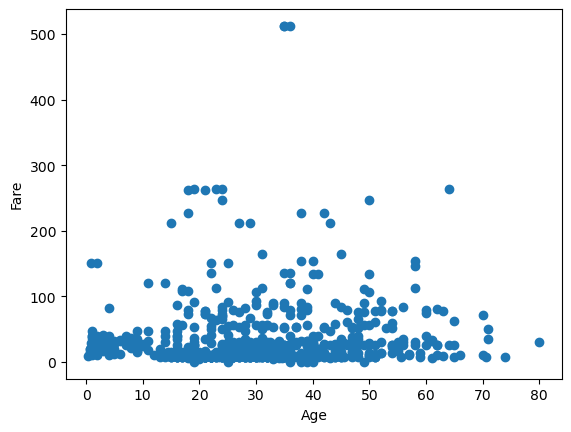

In [7]:
# 산점도
# 나이와 요금 간의 관계 확인
plt.scatter(df['age'], df['fare'])
plt.xlabel('Age'); plt.ylabel('Fare')
plt.show()

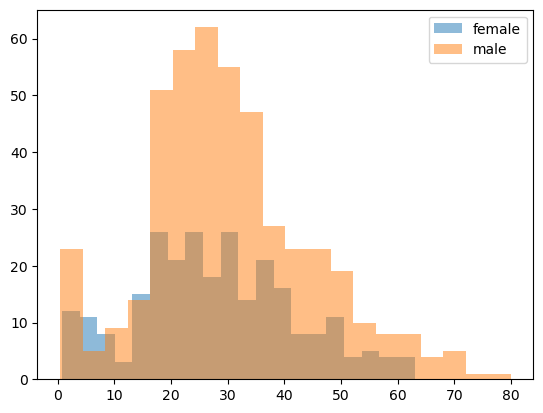

In [8]:
# 히스토그램
f_a = df.loc[df.sex=='female','age']
m_a = df.loc[df.sex=='male','age']
plt.hist(f_a.dropna(), bins=20, alpha=0.5, label='female')
plt.hist(m_a.dropna(), bins=20, alpha=0.5, label='male')
plt.legend()
plt.show()

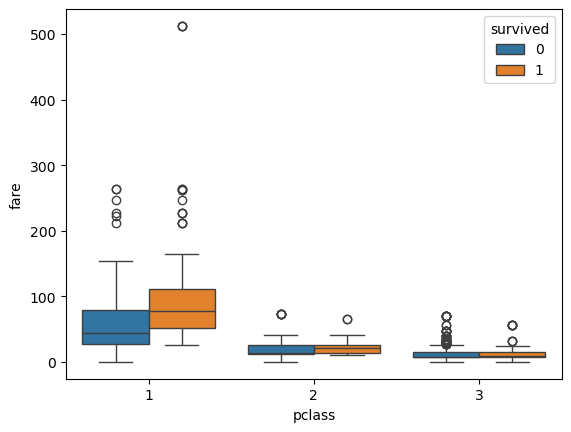

In [9]:
# 박스플롯 (이상치 확인)
sns.boxplot(data=df, x='pclass', y='fare', hue='survived')
plt.show()

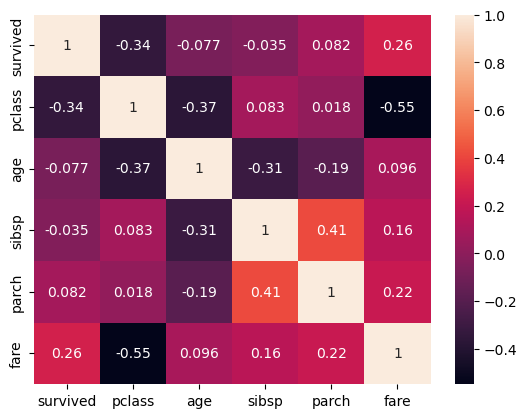

In [10]:
# 히트맵
numcols = ['survived','pclass','age','sibsp','parch','fare']
sns.heatmap(df[numcols].corr(), annot=True)
plt.show()

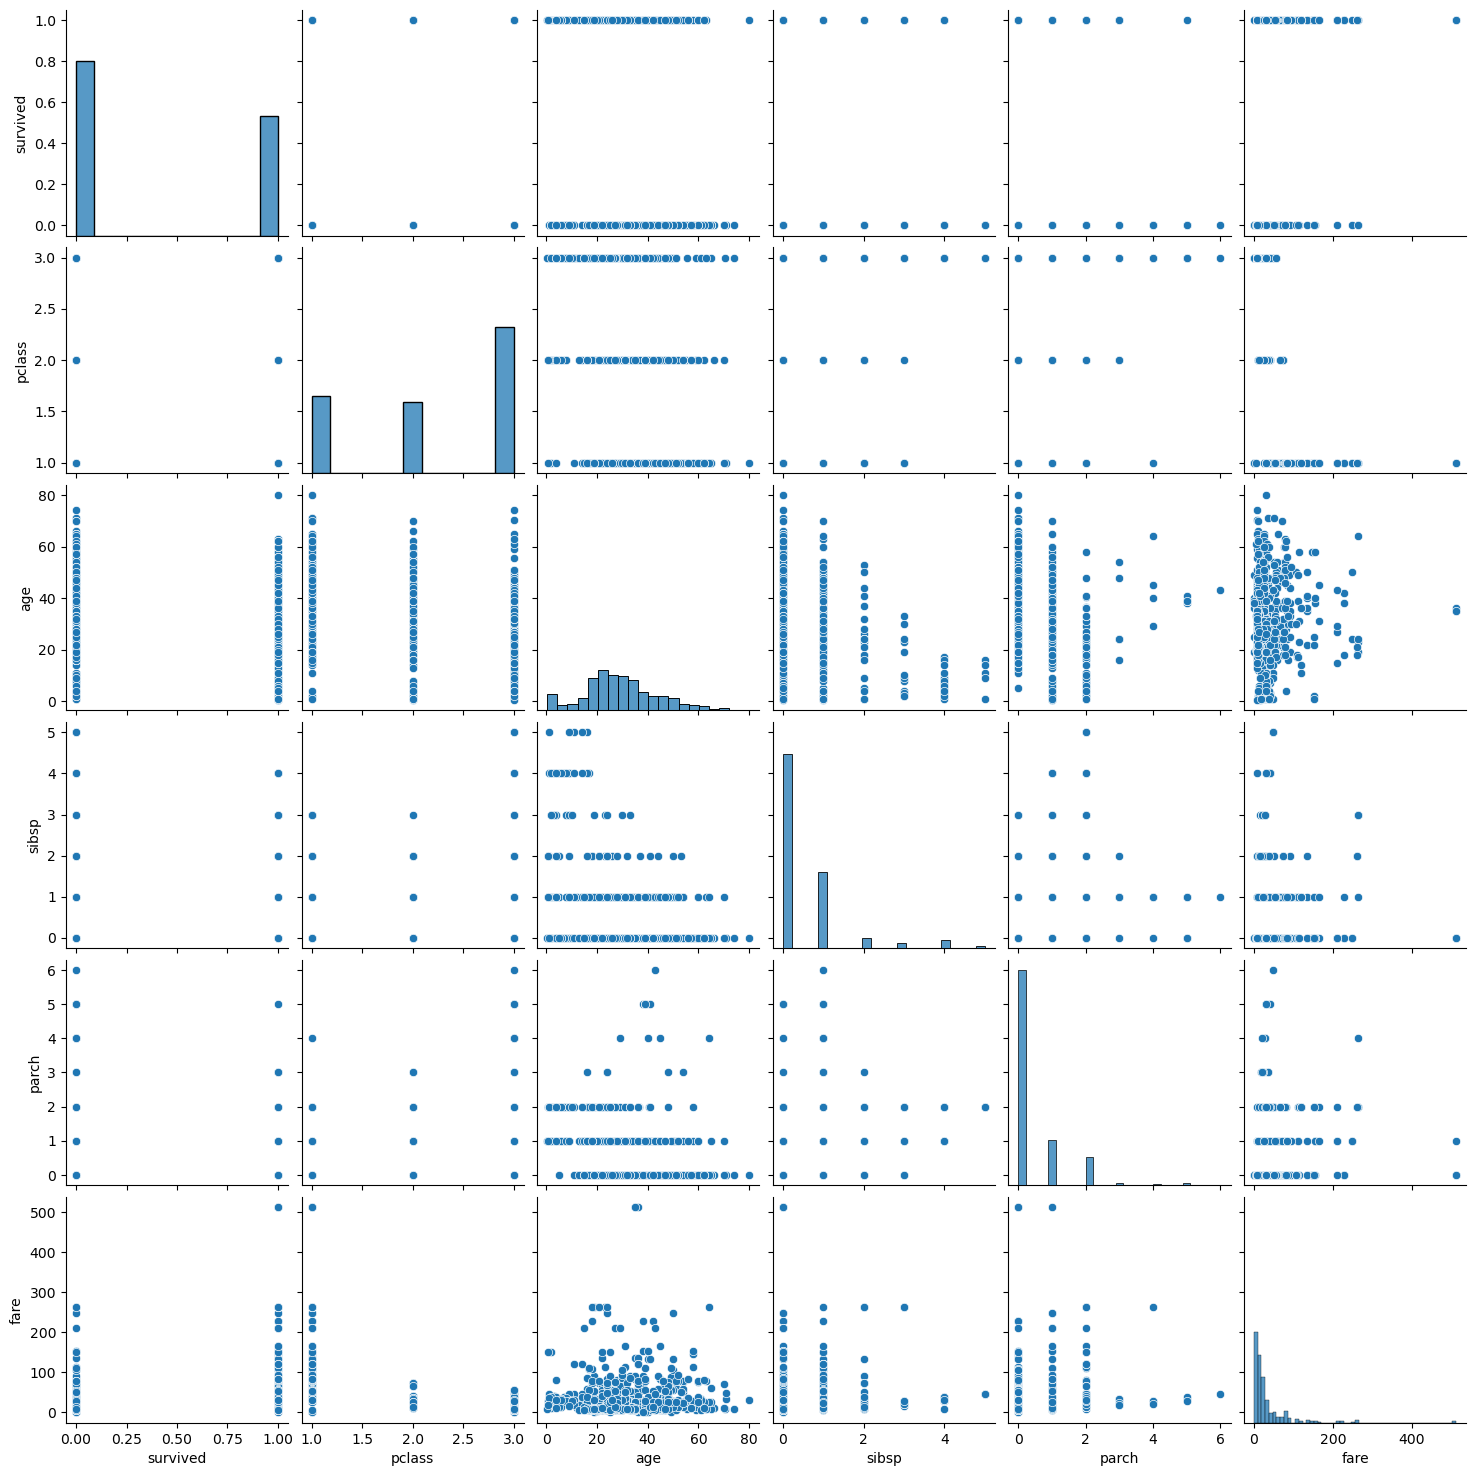

In [11]:
# pairplot
sns.pairplot(df[numcols].dropna())

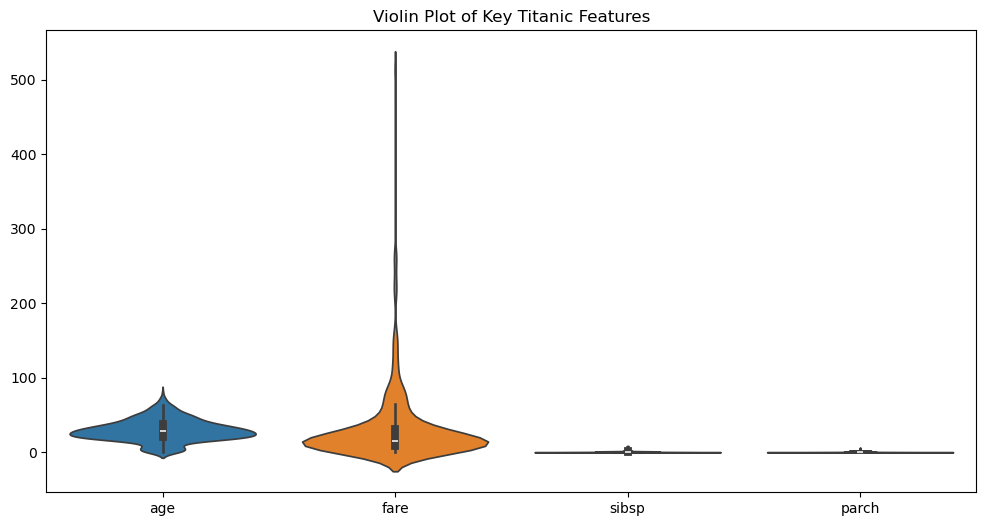

In [12]:
# 바이올린 플랏
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[['age','fare','sibsp','parch']])
plt.title("Violin Plot of Key Titanic Features")
plt.show()

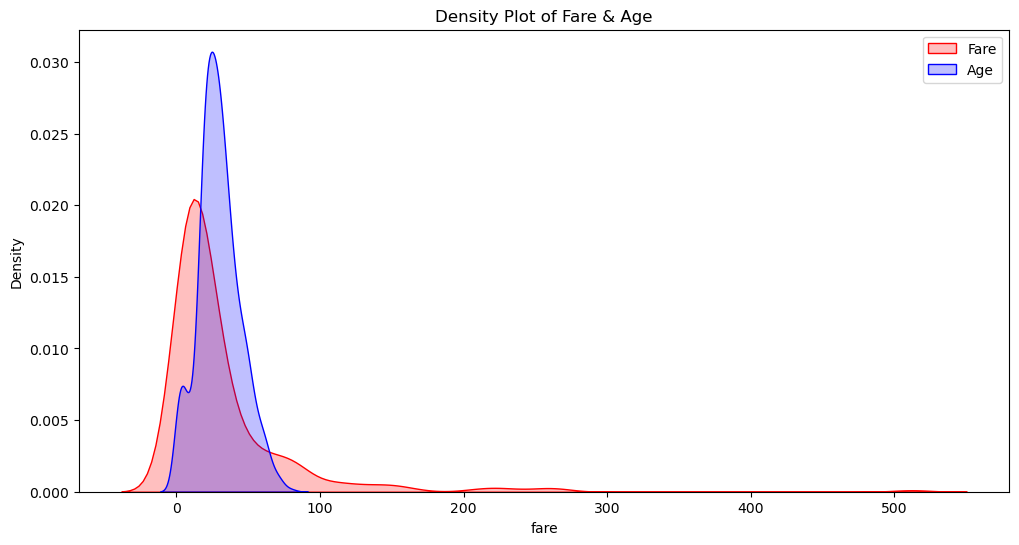

In [13]:
# 밀도 플롯 (Kernel Density Estimation, KDE)
plt.figure(figsize=(12, 6))
sns.kdeplot(df['fare'], fill=True, color='red', label='Fare')
sns.kdeplot(df['age'], fill=True, color='blue', label='Age')
plt.title("Density Plot of Fare & Age")
plt.legend()
plt.show()

### **이상치**

Q2. 주제를 보고 빈칸에 적절한 코드를 작성해 완성시켜 주세요

In [14]:
# 이상치 탐색 (IQR 사용) - fare 기준
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df['fare'] < (Q1 - 1.5 * IQR)) | (df['fare'] > (Q3 + 1.5 * IQR)))
print("이상치 개수:", outliers.sum())

이상치 개수: 116


### **데이터 전처리**

Q3. 주제를 보고 빈칸에 적절한 코드를 작성해 완성시켜 주세요.

In [15]:
# 결측치 처리
## SimpleImputer는 결측치를 채우는 방법을 제공하는 사이킷런의 클래스로,
## strategy='median'을 사용해 각 열의 중앙값으로 결측치를 채웁니다.
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

## 결측치가 너무 많은 deck 컬럼은 제거합니다.
df = df.drop(columns=['deck'])

# 이상치 제거 (앞에서 구한 Q1, Q3, IQR 활용)
df = df[~((df['fare'] < (Q1 - 1.5 * IQR)) | (df['fare'] > (Q3 + 1.5 * IQR)))]

# 범주형 데이터 처리
## get_dummies를 사용하여 범주형 변수를 원-핫 인코딩합니다.
## drop_first=True를 사용하여 첫번째 변수 제거 -> 더미변수 함정 방지
cat_cols = ['sex', 'embarked']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [16]:
# 데이터 전처리 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   age          775 non-null    float64 
 3   sibsp        775 non-null    int64   
 4   parch        775 non-null    int64   
 5   fare         775 non-null    float64 
 6   class        775 non-null    category
 7   who          775 non-null    object  
 8   adult_male   775 non-null    bool    
 9   embark_town  775 non-null    object  
 10  alive        775 non-null    object  
 11  alone        775 non-null    bool    
 12  sex_male     775 non-null    bool    
 13  embarked_Q   775 non-null    bool    
 14  embarked_S   775 non-null    bool    
dtypes: bool(5), category(1), float64(2), int64(4), object(3)
memory usage: 65.2+ KB


In [17]:
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,True,False,True
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,True,False,True
5,0,3,28.0,0,0,8.4583,Third,man,True,Queenstown,no,True,True,True,False


### **변수 선택 (랜덤포레스트 기반)**

In [18]:
# y에 가장 큰 영향을 주는 x를 분석하는 것이 목표

# 랜덤포레스트 작동 원리
#1. 데이터 샘플링 (여러개의 결정트리 생성)
#2. 트리학습 (샘플링된 데이터와 일부 랜덤 선택된 feature만 사용하여 학습)
#3. 결과 평균화 (여러 트리의 결과를 다수결/평균으로 최종 예측)

In [19]:
# 데이터 선택
x = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']]
y = df['survived']

# 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(x, y)

# 변수 중요도 계산 코드
## model 학습을 하면 feature_importances_ 속성 안에 변수중요도값이 저장되어 있습니다.
feature_importances = pd.Series(model.feature_importances_, index=x.columns)

# 출력
print("변수 중요도:\n", feature_importances.sort_values(ascending=False))

변수 중요도:
 fare        0.312249
age         0.297544
sex_male    0.237191
pclass      0.068942
sibsp       0.045198
parch       0.038877
dtype: float64


Q4. 결과값을 붙여놓고 어떤 변수가 'survived'와 가장 높은 상관관계를(중요도를) 갖는지 적어주세요.

In [20]:
# 결과값:
변수 중요도:
 fare        0.312249
age         0.297544
sex_male    0.237191
pclass      0.068942
sibsp       0.045198
parch       0.038877
dtype: float64
# 가장 중요한 변수: fare

SyntaxError: invalid syntax (2707056122.py, line 2)

### **차원 축소 & 스케일링**

Q5. 코드 내에 제시되어 있는 문제에 따라 코드를 작성해주세요.

In [ ]:
# 데이터 스케일링 (표준화)
## 평균=0, 분산=1로 변환시키는 코드를 빈칸에 작성해주세요.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# PCA 객체 생성 및 차원 축소
## n_components는 몇 개의 주성분으로 차원을 축소할 건지 결정합니다.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 출력
print("PCA 설명된 분산 비율:", pca.explained_variance_ratio_)

Q6. 아래 빈칸을 채워 출력값의 의미를 적어주세요.

A. 첫 번째 주성분(PC1)이 전체 데이터 분산의 약33%를 설명하고, 두 번째 주성분은 약29%를 설명합니다.

### **파생 변수**

In [ ]:
# 파생 변수 생성 예시
## family_size = 형제/배우자 수(sibsp) + 부모/자녀 수(parch) + 본인(1)
df['family_size'] = df['sibsp'] + df['parch'] + 1

## is_alone = 혼자 탑승했는지 여부
df['is_alone'] = (df['family_size'] == 1).astype(int)

## fare_per_person = 1인당 지불한 요금
df['fare_per_person'] = df['fare'] / df['family_size']

In [ ]:
df[['family_size', 'is_alone', 'fare_per_person', 'fare']].head()

Q7. 원하는 파생변수를 직접 생성해주세요.
  예시: 연령대(age_group), 등급×성별 조합, 요금 구간(fare_bin) 등

In [21]:
# Q8. 여기에 나만의 파생변수 생성 코드를 작성하세요.
# 나이와 객실 등급의 수치형 상호작용 (곱 연산)
df['age_pclass'] = df['age'] * df['pclass']

# 나이대와 객실 등급을 조합한 범주형 교호작용 변수
df['age_group'] = pd.cut(df['age'], bins=[0, 19, 60, 100], labels=['minor', 'adult', 'senior'])
df['age_group_pclass'] = df['age_group'].astype(str) + '_class' + df['pclass'].astype(str)

df[['age_pclass', 'age_group_pclass']].head()

,age_pclass,age_group_pclass
0,66.0,adult_class3
2,78.0,adult_class3
3,35.0,adult_class1
4,105.0,adult_class3
5,84.0,adult_class3
